# Week 1 — Vectors & the Building Blocks of Linear Algebra

This notebook covers the foundational concepts of linear algebra at the vector level —
the math behind every modern AI system, from word embeddings to neural networks.

**Topics covered:**
1. Vectors, linear combinations, and scalar multiplication
2. Dot product and cosine similarity
3. Vector norms (L1, L2, L∞)
4. Span, linear independence, basis, and rank

**Approach:** every concept is introduced with intuition, then implemented in NumPy,
then applied to a small quant example (financial returns).

## 1. Vectors & Linear Combinations

A **vector** is an ordered list of numbers that represents both a magnitude and 
a direction in space. Geometrically, you can think of it as an arrow starting at 
the origin and ending at the point given by its components.

Three core operations on vectors:

- **Scalar multiplication** — multiplying a vector by a number scales its length 
  (and flips its direction if the number is negative).
- **Vector addition** — adding two vectors places one at the tip of the other and 
  produces a third vector pointing to the result (tip-to-tail rule).
- **Linear combination** — scaling each vector by some number, then adding them. 

Mathematically, a linear combination looks like: c₁·v₁ + c₂·v₂ + ... + cₙ·vₙ

In [11]:
import numpy as np

# Two vectors in 2D
a = np.array([2, 3])
b = np.array([1, 4])

# Scalar multiplication
print("3a =", 3 * a)

# Vector addition
print("a + b =", a + b)

# Linear combination: 2a - b
print("2a - b =", 2*a - b)

3a = [6 9]
a + b = [3 7]
2a - b = [3 2]


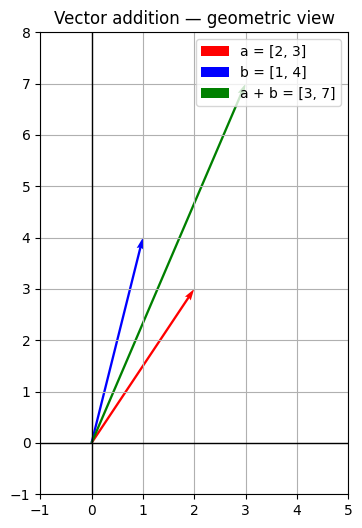

In [12]:
import matplotlib.pyplot as plt

sum_ab = a + b

plt.figure(figsize=(6, 6))
plt.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1,
           color='red', label='a = [2, 3]')
plt.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1,
           color='blue', label='b = [1, 4]')
plt.quiver(0, 0, sum_ab[0], sum_ab[1], angles='xy', scale_units='xy', scale=1,
           color='green', label='a + b = [3, 7]')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-1, 5)
plt.ylim(-1, 8)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title('Vector addition — geometric view')
plt.show()

The plot above shows two vectors `a` and `b` originating from the origin, and 
their sum `a + b`. Geometrically, vector addition follows the **tip-to-tail rule**: 
placing `b` at the tip of `a` lands you at the same point as the green arrow.

This simple operation, scaling and adding vectors — is the foundation of 
everything that follows.

## 2. Dot Product & Cosine Similarity

The **dot product** of two vectors is one of the most-used operations in modern AI. 
Every neuron computes one. Every embedding similarity check uses one.

There are two equivalent ways to compute it:

- **Algebraic:** multiply corresponding components and sum them.  
  `a · b = a₁b₁ + a₂b₂ + ... + aₙbₙ`

- **Geometric:** captures how aligned two vectors are.  
  `a · b = |a| · |b| · cos(θ)`

The same scalar comes out of both formulas — that's what makes the dot product so 
powerful. You can *compute* it the easy way (algebraic) and *interpret* it the 
meaningful way (geometric).

**What the sign tells you:**
- Positive → vectors point in similar directions (acute angle)
- Zero → vectors are perpendicular (orthogonal)
- Negative → vectors point in opposing directions

**Cosine similarity** normalizes the dot product by the vectors' lengths so the 
result lives in [−1, 1] regardless of magnitude. This is the math behind word 
embeddings, recommendation systems, and document similarity:

`cos_sim(a, b) = (a · b) / (|a| · |b|)`

Use raw dot product when magnitude carries information (neuron activations); 
use cosine similarity when only direction matters (comparing embeddings).

In [13]:
import numpy as np

a = np.array([2, 3])
b = np.array([1, 4])

# Three equivalent ways
print("np.dot(a, b)    =", np.dot(a, b))
print("a @ b           =", a @ b)
print("np.sum(a * b)   =", np.sum(a * b))

# Magnitudes
print("\n|a| =", np.linalg.norm(a))
print("|b| =", np.linalg.norm(b))

# Angle between them
cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
cos_theta = np.clip(cos_theta, -1.0, 1.0)
angle_deg = np.degrees(np.arccos(cos_theta))
print(f"\ncos(θ) = {cos_theta:.4f}")
print(f"Angle  = {angle_deg:.2f}°")

np.dot(a, b)    = 14
a @ b           = 14
np.sum(a * b)   = 14

|a| = 3.605551275463989
|b| = 4.123105625617661

cos(θ) = 0.9417
Angle  = 19.65°


In [14]:
def cosine_similarity(v1, v2):
    cos_t = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cos_t, -1.0, 1.0)))

a = np.array([2, 3])

print("Parallel     :", cosine_similarity(a, np.array([4, 6])))     # 0.0 degree
print("Perpendicular  :", cosine_similarity(a, np.array([3, -2])))    #  90 degree
print("Opposite       :", cosine_similarity(a, np.array([-2, -3])))   # 180 degree
print("Similar        :", cosine_similarity(a, np.array([1, 4])))     # 19.65 Similar

Parallel     : 0.0
Perpendicular  : 90.0
Opposite       : 180.0
Similar        : 19.653824058053292


In [15]:
# Hardcoded  returns for 3 stocks over 5 days
aapl = np.array([ 0.012, -0.005,  0.018,  0.003,  0.009])
msft = np.array([ 0.010, -0.004,  0.015,  0.005,  0.008])   # similar to AAPL
xom  = np.array([-0.008,  0.011, -0.004,  0.012, -0.007])   # different sector

print(f"AAPL vs MSFT (both tech) Similar as angle is actute:  {cosine_similarity(aapl, msft):.3f}")
print(f"AAPL vs XOM  (tech vs energy) Simialr as angle is obtuse: {cosine_similarity(aapl, xom):.3f}")

AAPL vs MSFT (both tech) Similar as angle is actute:  6.960
AAPL vs XOM  (tech vs energy) Simialr as angle is obtuse: 121.441


The output shows that AAPL and MSFT have a high cosine similarity — they tend to 
move together day-by-day. AAPL and XOM, in different sectors, are far less aligned.

This is the foundation of:
- **Pairs trading** — find correlated stocks, trade their divergence
- **Portfolio diversification** — combine assets with low pairwise similarity
- **Sector clustering** — group stocks by behavior, not by name

The same operation that compares word embeddings is comparing financial assets here.

## 3. Vector Norms (L1, L2, L∞)

A **norm** is a function that measures the "size" of a vector. There isn't just 
one way to measure size — there are several, and each one captures something 
slightly different.

For a vector `v = [v₁, v₂, ..., vₙ]`:

- **L1 norm** = `|v₁| + |v₂| + ... + |vₙ|`  
  Sum of absolute values. Also called "Manhattan distance" — the distance you'd 
  walk along city grid streets.

- **L2 norm** = `√(v₁² + v₂² + ... + vₙ²)`  
  Square root of sum of squares. This is the standard "straight-line" distance, 
  and a generalization of the Pythagorean theorem to any number of dimensions.

- **L∞ norm** = `max(|v₁|, |v₂|, ..., |vₙ|)`  
  The largest absolute value among the components. Captures the worst single 
  contribution to the vector's size.

**Key inequality:** for any vector, L1 ≥ L2 ≥ L∞. This is the math reason the 
L1 unit ball (diamond) is the smallest, the L2 unit ball (circle) sits in the 
middle, and the L∞ unit ball (square) is the largest.

**What each emphasizes:**
- **L1** treats every component equally — adding them all up linearly.
- **L2** squares each component before adding, so larger values dominate the total.
- **L∞** ignores all but the single largest component.

These differences in how each norm "weighs" the components matter when norms 
are used to measure errors or distances, which we explore below.

A useful way to compare the three is to plot the **uni

In [16]:

def l1_norm(v):
    return np.sum(np.abs(v))

def l2_norm(v):
    return np.sqrt(np.sum(v ** 2))

def linf_norm(v):
    return np.max(np.abs(v))

# Test on v = [3, -4]
v = np.array([3, -4])
print(f"v = {v}")
print(f"  L1 = {l1_norm(v)}")
print(f"  L2 = {l2_norm(v)}")
print(f"  L∞ = {linf_norm(v)}")

# Test on a 4-D vector
w = np.array([1, 1, 1, 1])
print(f"\nw = {w}")
print(f"  L1 = {l1_norm(w)}")
print(f"  L2 = {l2_norm(w)}")
print(f"  L∞ = {linf_norm(w)}")

v = [ 3 -4]
  L1 = 7
  L2 = 5.0
  L∞ = 4

w = [1 1 1 1]
  L1 = 4
  L2 = 2.0
  L∞ = 1


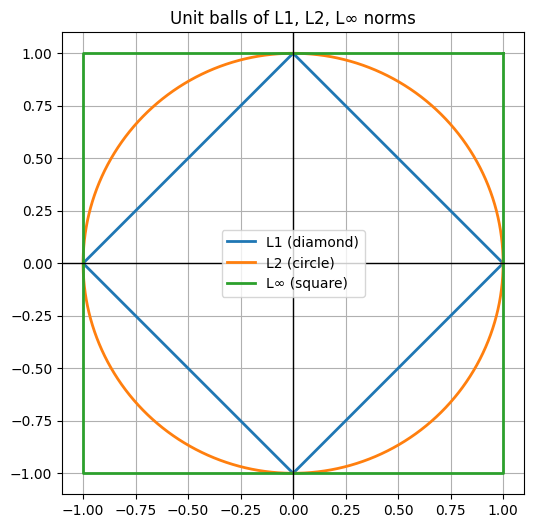

In [17]:

# L2: circle (sampled densely for smoothness)
theta = np.linspace(0, 2 * np.pi, 200)
l2_x = np.cos(theta)
l2_y = np.sin(theta)

# L1: diamond (4 corners + close)
l1_x = [1, 0, -1, 0, 1]
l1_y = [0, 1, 0, -1, 0]

# L∞: square (4 corners + close)
linf_x = [1, -1, -1, 1, 1]
linf_y = [1, 1, -1, -1, 1]

plt.figure(figsize=(6, 6))
plt.plot(l1_x, l1_y, label='L1 (diamond)', linewidth=2)
plt.plot(l2_x, l2_y, label='L2 (circle)', linewidth=2)
plt.plot(linf_x, linf_y, label='L∞ (square)', linewidth=2)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title('Unit balls of L1, L2, L∞ norms')
plt.show()

In [18]:
# Each portfolio holds 5 assets, with weights summing to 1.0
diversified  = np.array([0.20, 0.20, 0.20, 0.20, 0.20])   # equal weight
medium       = np.array([0.50, 0.20, 0.15, 0.10, 0.05])   # moderately concentrated
concentrated = np.array([0.80, 0.05, 0.05, 0.05, 0.05])   # mostly one stock

for name, p in [("Diversified", diversified),
                ("Medium", medium),
                ("Concentrated", concentrated)]:
    print(f"{name:14s}  L2 = {l2_norm(p):.3f}   L∞ = {linf_norm(p):.3f}")

Diversified     L2 = 0.447   L∞ = 0.200
Medium          L2 = 0.570   L∞ = 0.500
Concentrated    L2 = 0.806   L∞ = 0.800


The output shows that the diversified portfolio has the **lowest L2 norm** of its 
weights, while the concentrated portfolio has the highest. Because L2 squares 
each weight before summing, a single large weight (like 0.80) contributes far 
more than five equal weights of 0.20 each.

This gives us a quick numerical signal of portfolio concentration: **a smaller 
L2 norm of the weights = a more spread-out portfolio**.

The L∞ norm gives a different but related view — it tells you the size of the 
single largest position, which is a quick "biggest bet" check.

The takeaway: the choice of norm changes what aspect of a vector you're measuring.